<a href="https://colab.research.google.com/github/Joshabe1234/skinscan-ai/blob/master/SkinConditionClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [ ]:
BATCH_SIZE = 16
NUM_EPOCHS = 8
LR = 1e-3
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DIR = "/content/dataset/train"
VAL_DIR = "/content/dataset/val"

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet stats
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['acne', 'eczema', 'normal']


In [ ]:
# =========================
# MODEL (Pretrained ResNet18 - lighter than 50)
# =========================
model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


In [ ]:
# =========================
# LOSS & OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [ ]:
# =========================
# TRAIN FUNCTION
# =========================
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    accuracy = correct / len(loader.dataset)
    return total_loss / len(loader), accuracy

In [ ]:
# =========================
# VALIDATION FUNCTION
# =========================
def validate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    accuracy = correct / len(loader.dataset)
    return total_loss / len(loader), accuracy

In [ ]:
# =========================
# TRAIN LOOP
# =========================
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

Epoch 1/8
Train Loss: 0.9370 | Train Acc: 0.6744
Val   Loss: 5.4057 | Val   Acc: 0.6837
----------------------------------------
Epoch 2/8
Train Loss: 0.4978 | Train Acc: 0.8077
Val   Loss: 0.4954 | Val   Acc: 0.7857
----------------------------------------
Epoch 3/8
Train Loss: 0.4576 | Train Acc: 0.8256
Val   Loss: 0.3304 | Val   Acc: 0.8776
----------------------------------------
Epoch 4/8
Train Loss: 0.3863 | Train Acc: 0.8692
Val   Loss: 0.6382 | Val   Acc: 0.7857
----------------------------------------
Epoch 5/8
Train Loss: 0.3561 | Train Acc: 0.8692
Val   Loss: 0.3602 | Val   Acc: 0.8469
----------------------------------------
Epoch 6/8
Train Loss: 0.3430 | Train Acc: 0.8692
Val   Loss: 0.4679 | Val   Acc: 0.8163
----------------------------------------
Epoch 7/8
Train Loss: 0.2745 | Train Acc: 0.8821
Val   Loss: 0.2033 | Val   Acc: 0.9490
----------------------------------------
Epoch 8/8
Train Loss: 0.2650 | Train Acc: 0.9103
Val   Loss: 0.3819 | Val   Acc: 0.9082
---------

In [ ]:
# =========================
# SAVE MODEL
# =========================
torch.save(model.state_dict(), "skin_model.pth")

In [17]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}, "checkpoint.pth")

# Loading
checkpoint = torch.load("checkpoint.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

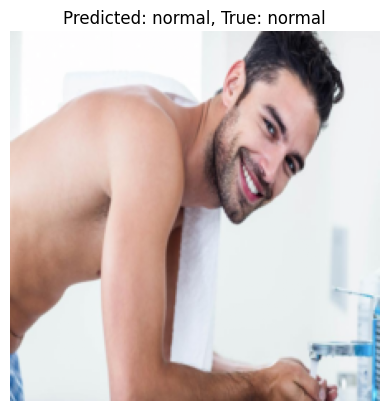

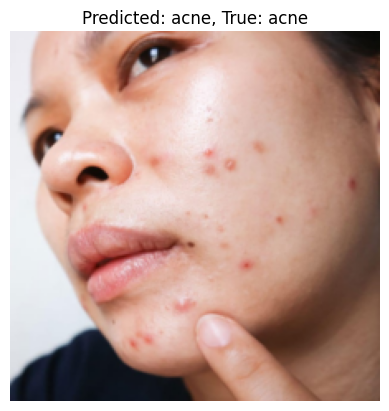

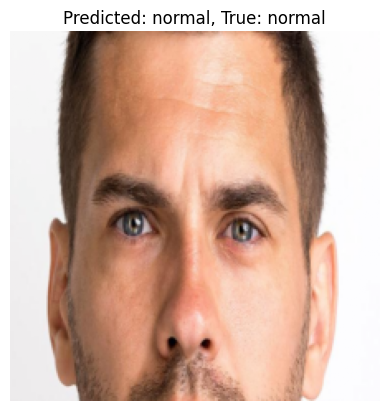

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random
from PIL import Image
import numpy as np

# Paths
VAL_DIR = "/content/dataset/val"
class_names = ['acne', 'eczema', 'normal']  # make sure this matches your classes

# Transform (same as used in training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load validation dataset
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

# Pick 3 random images
indices = random.sample(range(len(val_dataset)), 3)
images = [val_dataset[i][0] for i in indices]
labels = [val_dataset[i][1] for i in indices]

# Plot and predict
model.eval()  # set model to evaluation mode
with torch.no_grad():
    for i, img_tensor in enumerate(images):
        # Show image
        img = img_tensor.clone()
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)  # unnormalize
        npimg = img.numpy().transpose((1,2,0))
        plt.imshow(np.clip(npimg, 0, 1))
        plt.axis('off')

        # Predict
        input_tensor = img_tensor.unsqueeze(0)  # add batch dimension
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

        plt.title(f"Predicted: {class_names[pred.item()]}, True: {class_names[labels[i]]}")
        plt.show()

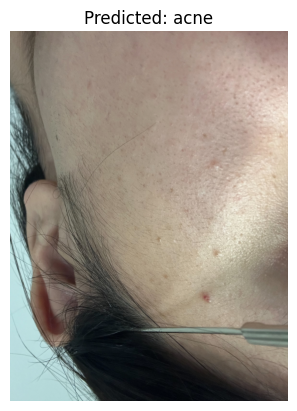

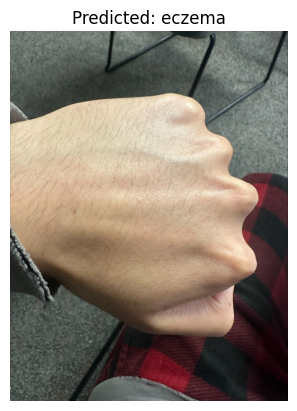

In [ ]:
image_paths = ["/content/acne-pic.jpeg", "/content/normal-pic.jpeg"]
class_names = ['acne', 'eczema', 'normal']  # make sure this matches your model classes

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Set model to evaluation mode
model.eval()

for img_path in image_paths:
    # Load and transform image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)  # add batch dimension

    # Make prediction
    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

    # Plot image with prediction
    img_np = np.array(img)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(f"Predicted: {class_names[pred.item()]}")
    plt.show()

In [ ]:
!pip install flask flask-cors pyngrok

import torch
import torch.nn as nn
from torchvision import models, transforms
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
from PIL import Image
import base64
import io

CLASS_NAMES = ['acne', 'eczema', 'normal']
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
model.load_state_dict(torch.load("skin_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f"✅ Model loaded on {DEVICE} with classes: {CLASS_NAMES}")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

CONDITION_INFO = {
    "acne": {
        "description": "This appears to be acne, a common skin condition where hair follicles become clogged with oil and dead skin cells. It typically presents as pimples, blackheads, or whiteheads.",
        "recommendations": [
            "Wash the affected area gently twice daily with a mild cleanser",
            "Apply an over-the-counter benzoyl peroxide or salicylic acid treatment",
            "Avoid touching or picking at the affected area"
        ],
        "see_doctor": False,
        "see_doctor_urgency": "none",
        "home_care": [
            "Use oil-free, non-comedogenic moisturizers and sunscreen",
            "Change pillowcases frequently and keep hair clean",
            "Stay hydrated and maintain a balanced diet"
        ]
    },
    "eczema": {
        "description": "This appears to be eczema (atopic dermatitis), a condition that causes skin to become inflamed, itchy, red, and rough. It often appears in patches and can flare up periodically.",
        "recommendations": [
            "Apply a fragrance-free moisturizer immediately after bathing",
            "Use an over-the-counter hydrocortisone cream for inflammation",
            "Identify and avoid triggers such as harsh soaps, stress, or allergens"
        ],
        "see_doctor": True,
        "see_doctor_urgency": "routine",
        "home_care": [
            "Take lukewarm (not hot) showers and pat skin dry gently",
            "Wear soft, breathable fabrics like cotton",
            "Use a humidifier to keep indoor air from getting too dry"
        ]
    },
    "normal": {
        "description": "Your skin appears healthy with no visible signs of common skin conditions. No concerning patterns of acne, eczema, or other issues were detected.",
        "recommendations": [
            "Continue your current skincare routine",
            "Wear sunscreen daily to protect against UV damage",
            "Stay hydrated and maintain a balanced diet for skin health"
        ],
        "see_doctor": False,
        "see_doctor_urgency": "none",
        "home_care": [
            "Moisturize daily to maintain skin barrier health",
            "Cleanse your face gently morning and night",
            "Get regular skin checkups annually"
        ]
    }
}

def get_severity(confidence, condition):
    if condition == "normal":
        return "mild"
    if confidence > 0.95:
        return "severe"
    if confidence > 0.85:
        return "moderate"
    return "mild"

def get_confidence_label(conf):
    if conf > 0.8:
        return "high"
    if conf > 0.5:
        return "medium"
    return "low"

app = Flask(__name__)
CORS(app)

@app.route('/api/analyze', methods=['POST'])
def analyze():
    try:
        data = request.json
        image_b64 = data.get('image')
        if not image_b64:
            return jsonify({"error": "No image provided"}), 400

        image_bytes = base64.b64decode(image_b64)
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            conf_val = confidence.item()
            pred_idx = predicted.item()

        condition = CLASS_NAMES[pred_idx]
        info = CONDITION_INFO[condition]

        result = {
            "condition": condition.capitalize() if condition != "normal" else "Healthy Skin",
            "confidence": get_confidence_label(conf_val),
            "severity": get_severity(conf_val, condition),
            "description": info["description"],
            "body_area": "skin",
            "recommendations": info["recommendations"],
            "see_doctor": info["see_doctor"],
            "see_doctor_urgency": info["see_doctor_urgency"],
            "home_care": info["home_care"]
        }
        return jsonify(result)

    except Exception as e:
        print(f"Error: {e}")
        return jsonify({"error": str(e)}), 500

@app.route('/health', methods=['GET'])
def health():
    return jsonify({"status": "ok", "classes": CLASS_NAMES})

ngrok.set_auth_token("3BaTAdmlgg1GYrRvpmcdUZMEKI6_TPfsjWDGy6CLsMjDyWKm")

public_url = ngrok.connect(5000)
print("\n" + "=" * 60)
print(f"🚀 API IS LIVE AT: {public_url.public_url}")
print("=" * 60)

app.run(port=5000)

✅ Model loaded on cpu with classes: ['acne', 'eczema', 'normal']

🚀 API IS LIVE AT: https://dakota-unmemorialized-prohibitively.ngrok-free.dev
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 19:53:09] "GET / HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 19:53:09] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 19:53:15] "GET / HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 19:53:24] "GET / HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 19:53:58] "GET / HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 19:56:06] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 20:07:39] "OPTIONS /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 20:07:39] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 20:07:53] "OPTIONS /api/analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [28/Mar/2026 20:07:55] "POST /api/analyze HTTP/1.1" 20